In [58]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import jax

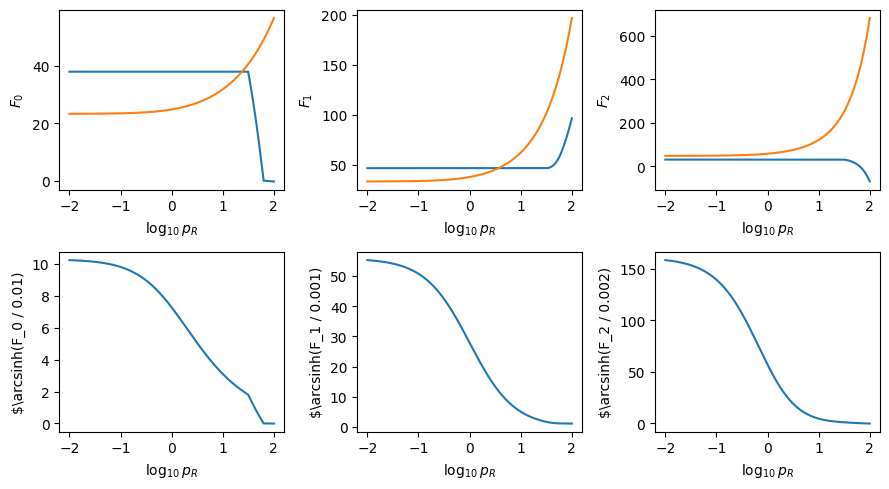

In [54]:
from train_mat import F_true
from physics import flux_from_primitive_state, GAMMA
from checkpoint import load_latest
from train_mat import _build_model, F_pred_nomat, flux_scale
from pathlib import Path

load_pred = False

FLUX_SCALE_ARCSINH = jnp.array([1e-2, 1e-3, 2e-3])

if load_pred:
    ckpt_dir = Path.cwd() / "checkpoints_hib1"
    F_net, _ = load_latest(ckpt_dir, _build_model)

Npix = 1000

log10rhoL_0, uL_0, log10pL_0 = 1.5, 1.2, 0.
log10rhoR_0, uR_0, log10pR_0 = 0., 0., 0.
t_0 = 0.5

# vary log10rhoR
log10pR = jnp.linspace(-2, 2, 1000)

# all others fixed
t = t_0 * jnp.ones_like(log10pR)
log10rhoL = log10rhoL_0 * jnp.ones_like(log10pR)
uL = uL_0 * jnp.ones_like(log10pR)
log10pL = log10pL_0 * jnp.ones_like(log10pR)
log10rhoR = log10rhoR_0 * jnp.ones_like(log10pR)
uR = uR_0 * jnp.ones_like(log10pR)
# log10pR = log10pR_0 * jnp.ones_like(log10pR)

x = jnp.vstack([t, log10rhoL, uL, log10pL, log10rhoR, uR, log10pR]).T

flux_L = jax.vmap(flux_from_primitive_state)(10.**log10rhoL, uL, 10.**log10pL)
flux_R = jax.vmap(flux_from_primitive_state)(10.**log10rhoR, uR, 10.**log10pR)
flux_LR = 0.5 * (flux_L + flux_R)

rho_ref = jnp.sqrt(10.**log10rhoL * 10.**log10rhoR)
a_L = jnp.sqrt(GAMMA * 10.**log10pL / 10.**log10rhoL)
a_R = jnp.sqrt(GAMMA * 10.**log10pR / 10.**log10rhoR)
a_ref = jnp.maximum(a_L + jnp.abs(uL), a_R + jnp.abs(uR))
# flux_ref = jnp.vstack([rho_ref*a_ref, rho_ref*a_ref**2, rho_ref*a_ref**3]).T

rho_L = 10.**log10rhoL
rho_R = 10.**log10rhoR
p_L = 10.**log10pL
p_R = 10.**log10pR
rho_c = 0.5 * (rho_L + rho_R)
p_c = 0.5 * (p_L + p_R)
a_c = jnp.sqrt(GAMMA * p_c / rho_c)
v_c = a_c + jnp.maximum(jnp.abs(uL), jnp.abs(uR))
flux_ref = jnp.vstack([rho_c*v_c, rho_c*v_c**2, rho_c*v_c**3]).T



# print(x[:10])

flux_true = jax.vmap(F_true)(x)
if load_pred:
    flux_pred = jax.vmap(lambda r: F_pred_nomat(F_net, r))(x)

F_scale = flux_scale(x)

fig, axs = plt.subplots(2, 3, figsize=(9, 5))

FLUX_SCALE = jnp.array([1e-2, 1e-3, 2e-3])

for i,ax in enumerate(axs[0]):
    ax.plot(log10pR, flux_true[:, i])
    ax.plot(log10pR, flux_ref[:, i])
    # ax.plot(log10pR, flux_pred[:, i])
    # ax.plot(log10pR, flux_true[:, i])
    # ax.plot(log10pR, flux_ref[:, i])
    ax.set_xlabel(r'$\log_{10} p_R$')
    ax.set_ylabel(r'$F_{}$'.format(i))

for i,ax in enumerate(axs[1]):
    # ax.plot(log10pR, jnp.arcsinh(flux_true[:, i] / FLUX_SCALE_ARCSINH[i]))
    # ax.plot(log10pR, jnp.arcsinh(flux_pred[:, i] / FLUX_SCALE_ARCSINH[i]))
    ax.plot(log10pR, flux_true[:, i] / F_scale[:, i])
    ax.set_xlabel(r'$\log_{10} p_R$')
    ax.set_ylabel(r'$\arcsinh(F_{} / {})'.format(i, FLUX_SCALE[i]))

fig.tight_layout()
plt.show()


In [55]:
from train_mat import FULL_BOUNDS, draw_rect

import jax.random as jr
key = jr.PRNGKey(0)

xs = [draw_rect(key, N, FULL_BOUNDS) for N in [100_000, 1_000_000, 10_000_000]]

flux_true = [jax.vmap(F_true)(x) for x in xs]
flux_pred = [jax.vmap(lambda r: F_pred_nomat(F_net, r))(x) for x in xs]
F_scale = [flux_scale(x) for x in xs]

def new_scale(x):
    rhoL, uL, pL = 10.0**x[:, 1], x[:, 2], 10.0**x[:, 3]
    rhoR, uR, pR = 10.0**x[:, 4], x[:, 5], 10.0**x[:, 6]
    rho_c = 0.5 * (rhoL + rhoR)
    p_c = 0.5 * (pL + pR)
    a_c = jnp.sqrt(GAMMA * p_c / rho_c)
    v_c = a_c + jnp.maximum(jnp.abs(uL), jnp.abs(uR))
    return jnp.stack([rho_c * v_c, rho_c * v_c**2, rho_c * v_c**3], axis=-1)

flux_scale_new = [new_scale(x) for x in xs]

In [21]:
flux_pred[0][:,0]

Array([-2.94152526, -4.17695232,  0.47533567, ..., -3.07431954,
       -0.35856014,  1.43478163], dtype=float64)

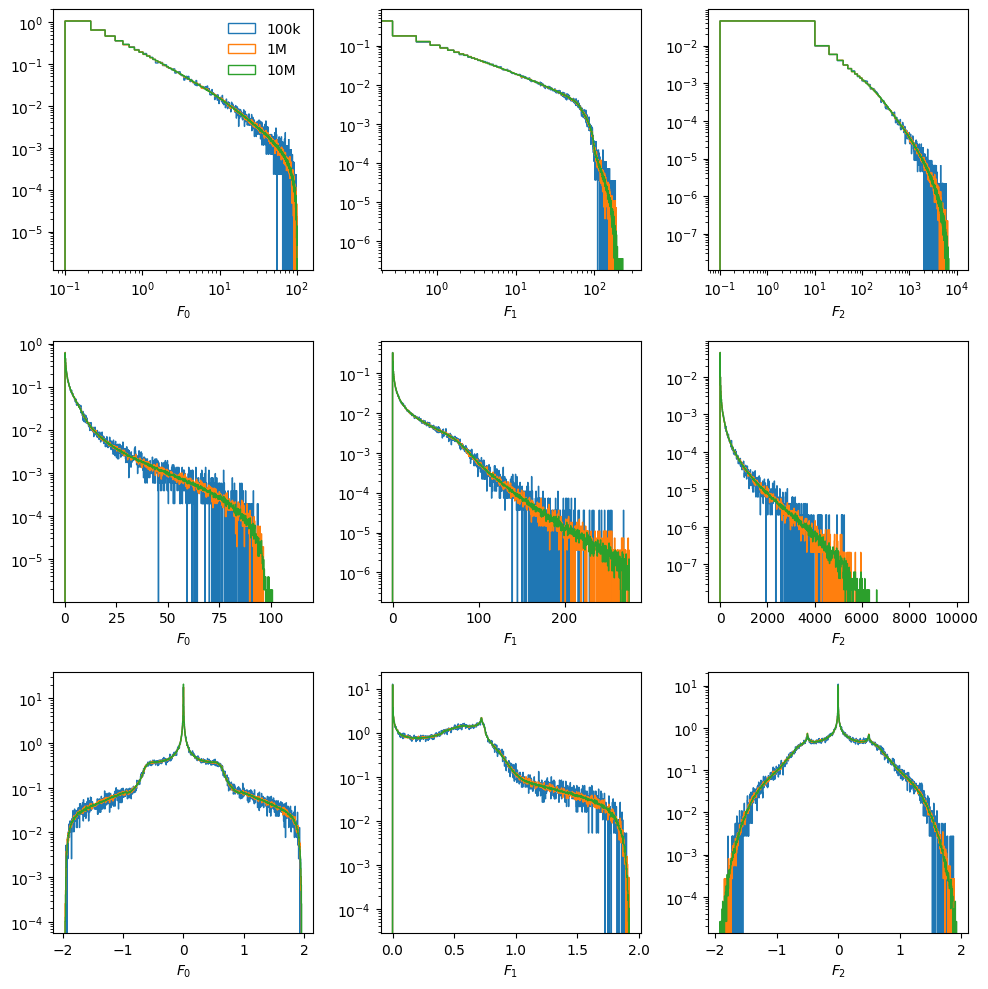

In [59]:
fig, axs = plt.subplots(3, 3, figsize=(10, 10))

FLUX_SCALE = jnp.array([1e-2, 1e-3, 2e-3])

bins = [jnp.linspace(0.1, 115, 1000), jnp.linspace(0, 275, 1000), jnp.linspace(0.1, 10000, 1000)]
labels = ['100k', '1M', '10M']
for i,ax in enumerate(axs[0]):
    for j,x in enumerate(xs):
        ax.hist(flux_true[j][:, i], bins=bins[i], density=True, histtype='step', label=labels[j])
        ax.set_xlabel(r'$F_{}$'.format(i))
        ax.set_yscale('log')
        ax.set_xscale('log')
    # print(ax.get_xlim())
axs[0][0].legend(frameon=False, fontsize=10)

for i,ax in enumerate(axs[1]):
    for j,x in enumerate(xs):
        ax.hist(flux_pred[j][:,i], bins=bins[i], density=True, histtype='step')
        ax.set_xlabel(r'$F_{}$'.format(i))
        ax.set_yscale('log')
    # print(ax.get_xlim())

for i,ax in enumerate(axs[2]):
    for j,x in enumerate(xs):
        ax.hist(flux_true[j][:,i]/flux_scale_new[j][:,i], bins=1000, density=True, histtype='step')
        ax.set_xlabel(r'$F_{}$'.format(i))
        ax.set_yscale('log')
    # print(ax.get_xlim())

fig.tight_layout()
plt.show()

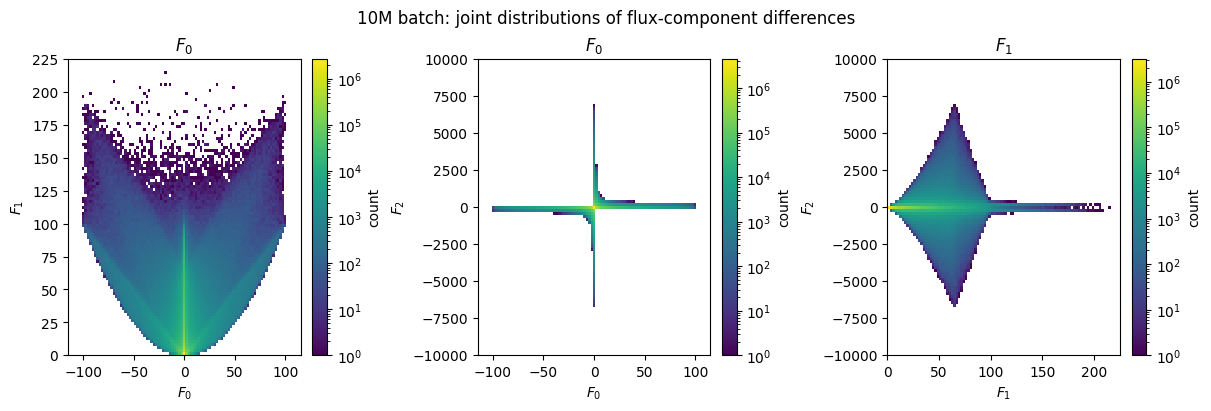

In [6]:
from matplotlib.colors import LogNorm
import numpy as np

j = 2  # 10M batch
F = flux_true[j]
# print(flux_true.shape)

F0 = F[:, 0]
F1 = F[:, 1]
F2 = F[:, 2]

panels = [
    (F0, F1, r'$F_0$', r'$F_1$', r'$F_0$', ((-115, 115), (0, 225))),
    (F0, F2, r'$F_0$', r'$F_2$', r'$F_0$', ((-115, 115), (-10000, 10000))),
    (F1, F2, r'$F_1$', r'$F_2$', r'$F_1$', ((0, 225), (-10000, 10000))),
]

N = 100

fig, axs = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
for ax, (x, y, xlabel, ylabel, title, lims) in zip(axs, panels):
    x_np = np.asarray(x)
    y_np = np.asarray(y)
    # lim = np.nanpercentile(np.concatenate([x_np, y_np]), [0.5, 99.5])
    bins = [np.linspace(lims[0][0], lims[0][1], N), np.linspace(lims[1][0], lims[1][1], N)]
    h = ax.hist2d(x_np, y_np, bins=bins, norm=LogNorm(), cmap='viridis')
    fig.colorbar(h[3], ax=ax, label='count')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set(xlim=lims[0], ylim=lims[1])

fig.suptitle('10M batch: joint distributions of flux-component differences')
plt.show()

(10000000, 3)


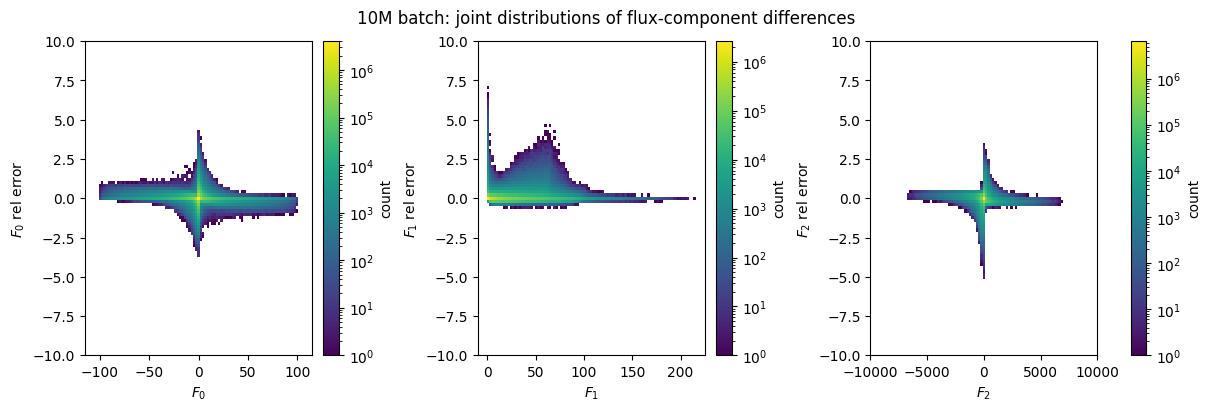

In [18]:
from matplotlib.colors import LogNorm
import numpy as np

j = 2  # 10M batch
F = flux_true[j]
# print(flux_true.shape)

EPS_REL = jnp.array([10, 5, 50])

err = (flux_pred[j] - flux_true[j]) / (jnp.abs(flux_true[j]) + EPS_REL)
print(err.shape)

F0 = F[:, 0]
F1 = F[:, 1]
F2 = F[:, 2]

panels = [
    (F0, err[:,0], r'$F_0$', r'$F_0$ rel error', r'', ((-115, 115), (-10, 10))),
    (F1, err[:,1], r'$F_1$', r'$F_1$ rel error', r'', ((-10, 225), (-10, 10))),
    (F2, err[:,2], r'$F_2$', r'$F_2$ rel error', r'', ((-10000, 10000), (-10, 10))),
]

N = 100

fig, axs = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
for ax, (x, y, xlabel, ylabel, title, lims) in zip(axs, panels):
    x_np = np.asarray(x)
    y_np = np.asarray(y)
    # lim = np.nanpercentile(np.concatenate([x_np, y_np]), [0.5, 99.5])
    bins = [np.linspace(lims[0][0], lims[0][1], N), np.linspace(lims[1][0], lims[1][1], N)]
    h = ax.hist2d(x_np, y_np, bins=bins, norm=LogNorm(), cmap='viridis')
    fig.colorbar(h[3], ax=ax, label='count')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set(xlim=lims[0], ylim=lims[1])

fig.suptitle('10M batch: joint distributions of flux-component differences')
plt.show()

0.05522213552605722


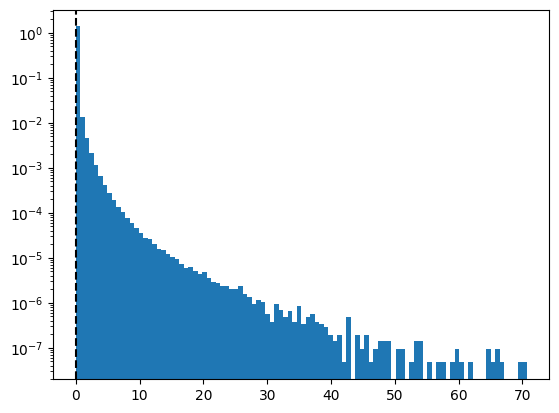

In [29]:
j = 2
loss_vals = jnp.abs(flux_pred[j] - flux_true[j]) ** 2 / (jnp.abs(flux_true[j]) + EPS_REL)**2
print(jnp.mean(loss_vals))
plt.hist(loss_vals.ravel(), bins=100, density=True)
plt.axvline(jnp.mean(loss_vals), color='k', linestyle='--')
plt.yscale('log')
plt.show()


In [45]:
j = 2
err = (flux_pred[j] - flux_true[j]) / (jnp.abs(flux_true[j]) + EPS_REL)
print(err.shape)

keys_sorted = jnp.argsort(jnp.abs(flux_true[2]), axis=0)

for j in [-1, -2, -3]:
    keys = keys_sorted[j]
    name = ['mass', 'momentum', 'energy']
    for k,n in zip(keys_sorted[j], name):
        print(n)
        print('err/loss_vals:', err[k], loss_vals[k])
        print('flux true/pred:', flux_true[2][k], flux_pred[2][k])
        print('UL:', xs[j][k][1:4])
        print('UR:', xs[j][k][4:7])
        print('-----')


(10000000, 3)
mass
err/loss_vals: [-0.04238065  0.00451387  0.01940734] [1.79611960e-03 2.03750061e-05 3.76645016e-04]
flux true/pred: [-100.78662823  195.62401442 -296.64118526] [-105.48183769  196.52960478 -289.91380039]
UL: [-1.01103514 -0.28788694 -1.89422254]
UR: [ 1.99523717 -0.9952931   1.99167596]
-----
momentum
err/loss_vals: [0.03318848 0.05224668 0.05417764] [0.00110148 0.00272972 0.00293522]
flux true/pred: [ -38.98628716  227.55022065 -131.07911165] [ -37.36050659  239.70019731 -121.26867202]
UL: [1.85069227 0.75840514 1.84205989]
UR: [ 1.9990686  -0.93926557  1.9666921 ]
-----
energy
err/loss_vals: [ 1.3322061   3.22514832 -0.08117929] [1.77477310e+00 1.04015817e+01 6.59007668e-03]
flux true/pred: [3.52788038e-01 6.56601416e+01 6.78284824e+03] [  14.14483544  293.5495785  6228.16248966]
UL: [-1.98603346  0.50716576  1.99714287]
UR: [-1.91256007  0.2523802  -1.51313141]
-----
mass
err/loss_vals: [0.00617053 0.00560267 0.0011533 ] [3.80754678e-05 3.13898892e-05 1.33009461e-

In [50]:
j = 2
err = (flux_pred[j] - flux_true[j]) / (jnp.abs(flux_true[j]) + EPS_REL)
loss_vals = jnp.abs(flux_pred[j] - flux_true[j]) ** 2 / (jnp.abs(flux_true[j]) + EPS_REL)**2
print(err.shape)

keys_sorted = jnp.argsort(loss_vals, axis=0)

name = ['mass', 'momentum', 'energy']
for k in [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10]:
    for key,n in zip(keys_sorted[k], name):
        print(n, 'loss_val:', loss_vals[key])
        print('flux true/pred:', flux_true[2][key], flux_pred[2][key])
        print('UL:', xs[j][key][1:4])
        print('UR:', xs[j][key][4:7])
    print('-----')


(10000000, 3)
mass loss_val: [1.55089826e+01 4.23678297e+00 1.77567048e-03]
flux true/pred: [-3.79848283e-01  6.45637498e+01 -6.59528042e+03] [  -41.25719138   207.74992677 -6315.25690772]
UL: [-1.95657614 -0.93189543 -1.06823909]
UR: [-1.95099659 -0.90767315  1.99170557]
momentum loss_val: [6.29111886e-02 5.33502953e+01 2.47576696e-02]
flux true/pred: [0. 0. 0.] [-2.50821029 36.52064325 -7.86728505]
UL: [ 1.95265103 -0.98946748 -0.35591934]
UR: [1.97850154 0.99955454 0.05091636]
energy loss_val: [1.93236510e-01 1.31344126e-03 7.06624065e+01]
flux true/pred: [2.46359457e-04 1.00693824e+02 5.58161571e+00] [ -4.39572943 104.52431911 472.80586932]
UL: [-1.95724509  0.86937652  1.9980074 ]
UR: [ 1.53436393 -0.76882107  1.64550018]
-----
mass loss_val: [14.2418234   0.03476529  0.1300542 ]
flux true/pred: [-1.49744851e-03  8.12297417e+01 -1.10932500e-01] [ 37.74249413  97.30766755 -18.1824522 ]
UL: [ 1.99099085  0.78738365 -1.17175761]
UR: [0.48806622 0.82624796 1.99324515]
momentum loss_va